data.csv
   ↓
1. LOAD & INSPECT
   - Shape, dtypes, missing values, duplicates
   ↓
2. EDA
   - Class balance
   - Text length analysis (title + text)
   - Subject distribution
   - Date timeline
   - Top words fake vs real
   ↓
3. PREPROCESSING
   - Drop nulls / duplicates
   - Clean text (lowercase, remove URLs, punctuation)
   - Combine title + text
   ↓
4. TRAIN / TEST SPLIT (80/20 stratified)
   ↓
5. FEATURE EXTRACTION
   - TF-IDF (title+text, bigrams, 50k features)
   ↓
6. BASELINE MODELS
   - Majority Class    ← dumbest baseline
   - Naive Bayes       ← simple NLP baseline
   - Logistic Regression ← strong NLP baseline
   ↓
7. ADVANCED MODELS
   - Random Forest
   - Gradient Boosting
   ↓
8. EVALUATE ALL MODELS
   - Accuracy, Precision, Recall, F1, AUC-ROC
   - Confusion matrix
   - Model comparison chart
   ↓
9. BEST MODEL — deep dive
   - Top predictive words
   - Error analysis (what did it get wrong?)
   ↓
10. PREDICT ON validation_data.csv
    - Replace label=2 with 0/1
    - Save predictions.csv
    ↓
11. SAVE EVERYTHING
    - results/summary.json
    - results/predictions.csv
    - results/all plots

In [147]:
# ══════════════════════════════════════════════════════════════════
# FAKE NEWS CLASSIFIER — Full Pipeline
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import json, re, os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

In [148]:
# ══════════════════════════════════════════════════════════════════
# 1. LOAD DATA & INSPECT
# ══════════════════════════════════════════════════════════════════

df  = pd.read_csv("dataset/data.csv")
val = pd.read_csv("dataset/validation_data.csv")

print("── Training data ──────────────────────────")
print(df.shape)
print(df["label"].value_counts())
print(df.head(3))

print("\n── Validation data ────────────────────────")
print(val.shape)
print(val["label"].value_counts())   # should be all 2s


print("── Shape ───────────────────────────────────")
print(df.shape)

print("\n── Data Types ──────────────────────────────")
print(df.dtypes)

print("\n── Missing Values ──────────────────────────")
print(df.isnull().sum())

print("\n── Sample Rows ─────────────────────────────")
print(df.head(5))

print("\n── Label Distribution ──────────────────────")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")


── Training data ──────────────────────────
(39942, 5)
label
1    19999
0    19943
Name: count, dtype: int64
   label                                              title  \
0      1  As U.S. budget fight looms, Republicans flip t...   
1      1  U.S. military to accept transgender recruits o...   
2      1  Senior U.S. Republican senator: 'Let Mr. Muell...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
2  December 31, 2017   

── Validation data ────────────────────────
(4956, 5)
label
2    4956
Name: count, dtype: int64
── Shape ───────────────────────────────────
(39942, 5)

── Data Types ──────────────────────────────
label       int64
title      object
text       object
subject 

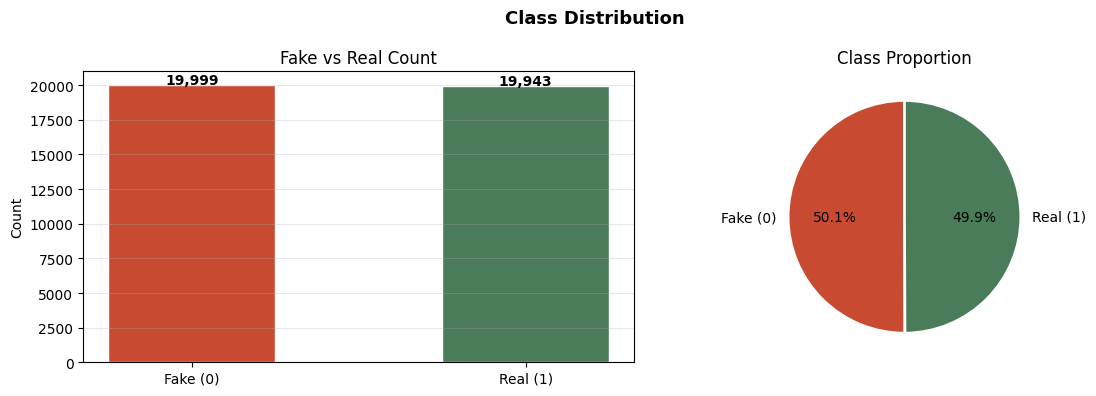

In [149]:
# ══════════════════════════════════════════════════════════════════
# 2. EDA
# ══════════════════════════════════════════════════════════════════

# ── Plot 1: Class balance ──────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Class Distribution", fontsize=13, fontweight="bold")

# Count plot
counts = df["label"].value_counts()
colors = ["#c84b31", "#4a7c59"]
axes[0].bar(["Fake (0)", "Real (1)"], counts.values, color=colors, edgecolor="white", width=0.5)
axes[0].set_ylabel("Count")
axes[0].set_title("Fake vs Real Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontsize=10, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Pie chart
axes[1].pie(counts.values, labels=["Fake (0)", "Real (1)"],
            colors=colors, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class Proportion")

plt.tight_layout()
plt.savefig("results/eda_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()



── Title Length (words) ────────────────────
         count  mean  std  min   25%   50%   75%   max
label                                                 
0      19943.0  14.8  4.2  1.0  12.0  14.0  17.0  42.0
1      19999.0   9.9  1.7  4.0   9.0  10.0  11.0  20.0

── Text Length (words) ─────────────────────
         count   mean    std  min    25%    50%    75%     max
label                                                         
0      19943.0  396.9  296.7  0.0  252.0  366.0  495.0  7033.0
1      19999.0  386.5  275.6  0.0  146.0  361.0  527.0  5172.0


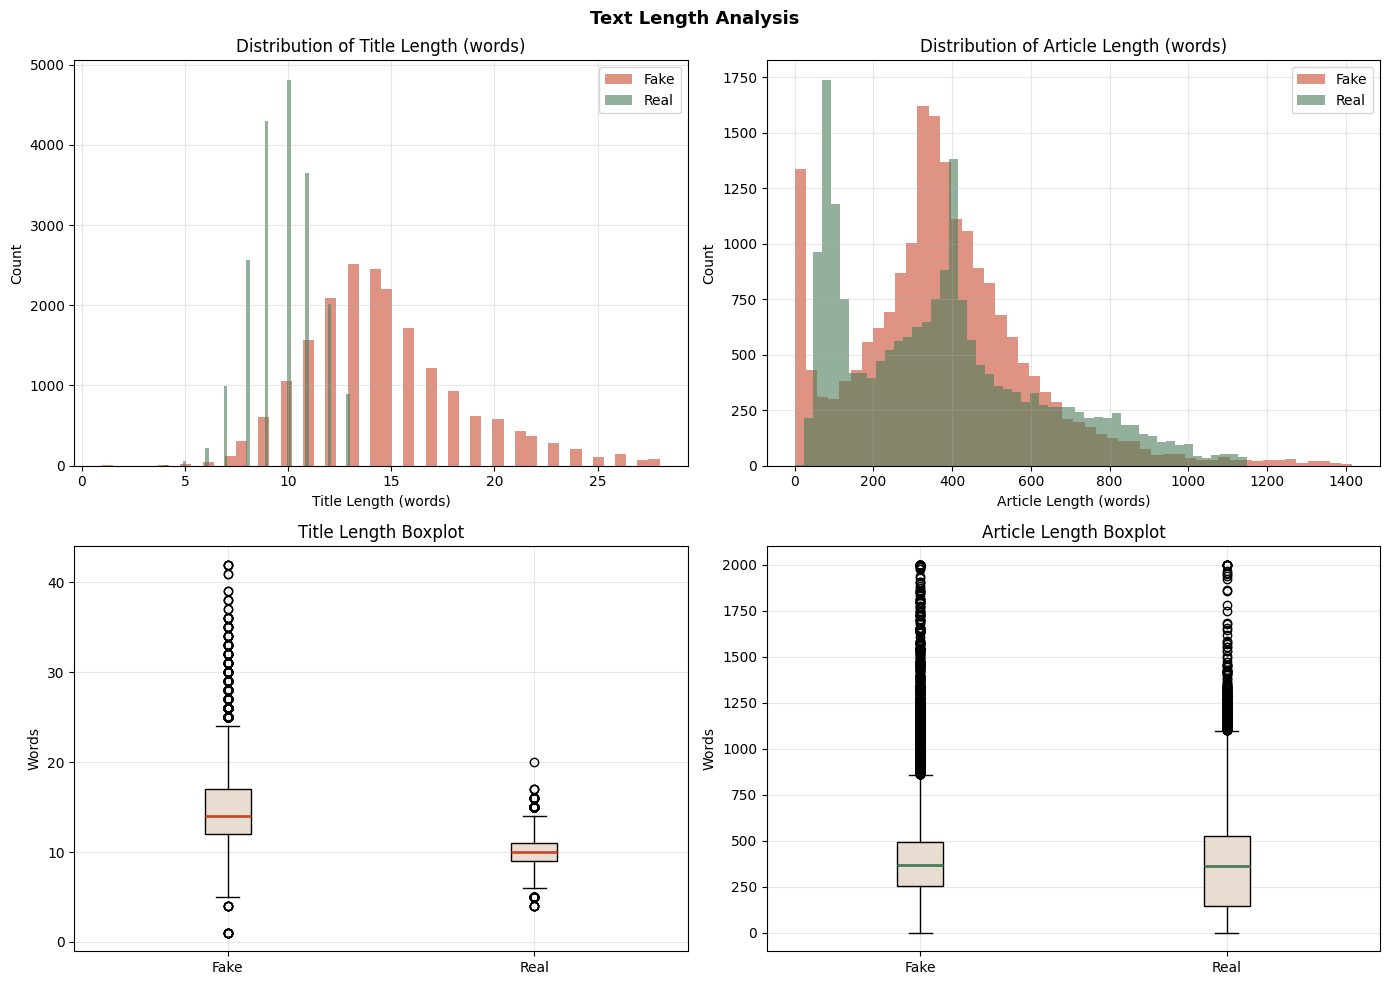

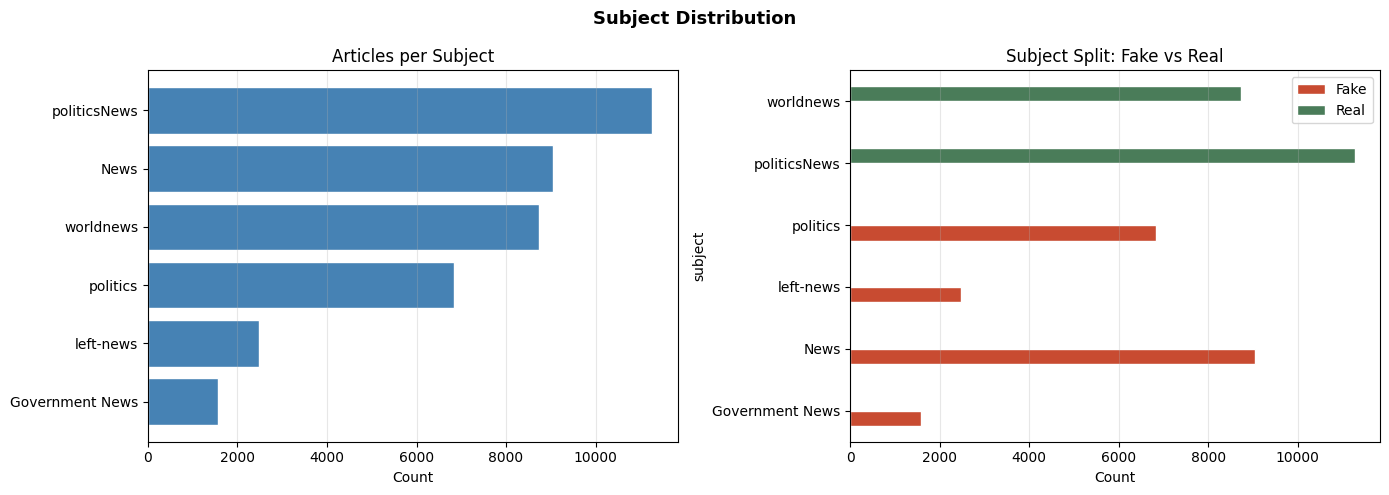


Subject counts:
subject
politicsNews       11272
News                9050
worldnews           8727
politics            6841
left-news           2482
Government News     1570
Name: count, dtype: int64


In [150]:
# ── Plot 2: Text length distributions ─────────────────────────────


df["title_len"]   = df["title"].fillna("").apply(lambda x: len(x.split()))
df["text_len"]    = df["text"].fillna("").apply(lambda x: len(x.split()))
df["title_chars"] = df["title"].fillna("").apply(len)

print("\n── Title Length (words) ────────────────────")
print(df.groupby("label")["title_len"].describe().round(1))

print("\n── Text Length (words) ─────────────────────")
print(df.groupby("label")["text_len"].describe().round(1))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Text Length Analysis", fontsize=13, fontweight="bold")

for ax, (col, title) in zip(axes.flatten(), [
    ("title_len",  "Title Length (words)"),
    ("text_len",   "Article Length (words)"),
]):
    for label, color, name in [(0, "#c84b31", "Fake"), (1, "#4a7c59", "Real")]:
        data = df[df["label"] == label][col]
        data = data[data < data.quantile(0.99)]  # remove extreme outliers for display
        ax.hist(data, bins=50, alpha=0.6, color=color, label=name, edgecolor="none")
    ax.set_xlabel(title); ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {title}")
    ax.legend(); ax.grid(alpha=0.3)

# Box plots
axes[1][0].boxplot(
    [df[df["label"]==0]["title_len"].clip(upper=50),
     df[df["label"]==1]["title_len"].clip(upper=50)],
    labels=["Fake", "Real"], patch_artist=True,
    boxprops=dict(facecolor="#e8ddd0"),
    medianprops=dict(color="#c84b31", linewidth=2)
)
axes[1][0].set_title("Title Length Boxplot"); axes[1][0].set_ylabel("Words")
axes[1][0].grid(alpha=0.3)

axes[1][1].boxplot(
    [df[df["label"]==0]["text_len"].clip(upper=2000),
     df[df["label"]==1]["text_len"].clip(upper=2000)],
    labels=["Fake", "Real"], patch_artist=True,
    boxprops=dict(facecolor="#e8ddd0"),
    medianprops=dict(color="#4a7c59", linewidth=2)
)
axes[1][1].set_title("Article Length Boxplot"); axes[1][1].set_ylabel("Words")
axes[1][1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results/eda_text_length.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 3: Subject distribution ───────────────────────────────────

if "subject" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Subject Distribution", fontsize=13, fontweight="bold")

    subj_counts = df["subject"].value_counts()
    axes[0].barh(subj_counts.index[::-1], subj_counts.values[::-1],
                 color="steelblue", edgecolor="white")
    axes[0].set_title("Articles per Subject")
    axes[0].set_xlabel("Count"); axes[0].grid(axis="x", alpha=0.3)

    subj_label = df.groupby(["subject", "label"]).size().unstack(fill_value=0)
    subj_label.columns = ["Fake", "Real"]
    subj_label.plot(kind="barh", ax=axes[1],
                    color=["#c84b31", "#4a7c59"], edgecolor="white")
    axes[1].set_title("Subject Split: Fake vs Real")
    axes[1].set_xlabel("Count"); axes[1].grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.savefig("results/eda_03_subjects.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nSubject counts:\n{subj_counts}")


Date range: 2016-01-13 → 2017-12-31
Total rows            : 39942

Valid dates by label:
label
0        0
1    19999
Name: date_parsed, dtype: int64

NULL dates by label:
label
0    19943
1        0
Name: date_parsed, dtype: int64

Sample raw dates — FAKE (label=0):
['December 31, 2017', 'December 31, 2017', 'December 30, 2017', 'December 29, 2017', 'December 25, 2017', 'December 25, 2017', 'December 23, 2017', 'December 23, 2017', 'December 22, 2017', 'December 21, 2017']

Sample raw dates — REAL (label=1):
['December 31, 2017 ', 'December 29, 2017 ', 'December 31, 2017 ', 'December 30, 2017 ', 'December 29, 2017 ', 'December 29, 2017 ', 'December 29, 2017 ', 'December 29, 2017 ', 'December 29, 2017 ', 'December 28, 2017 ']


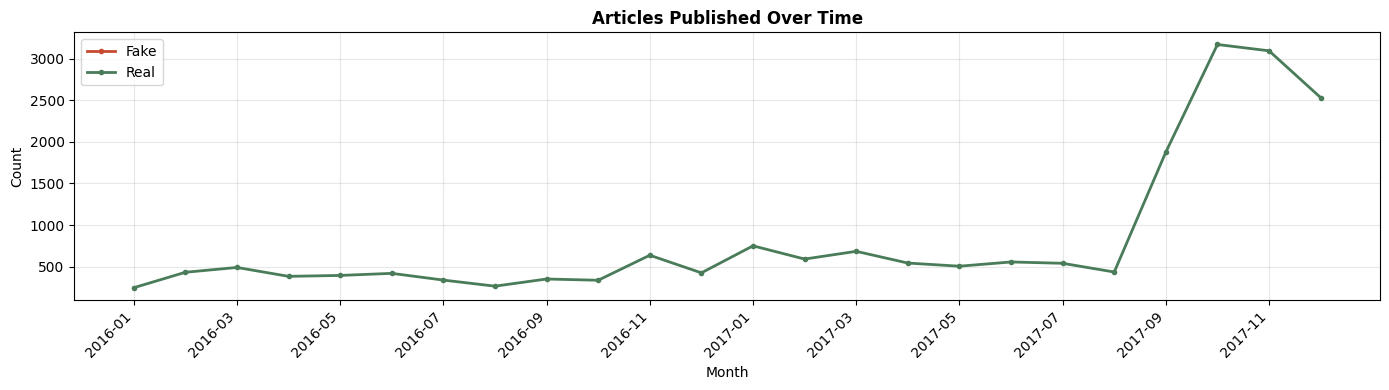

In [151]:
# ── Plot 4: Date timeline ──────────────────────────────────────────
if "date" in df.columns:
    df["date_parsed"] = pd.to_datetime(df["date"], errors="coerce")
    df["year_month"]  = df["date_parsed"].dt.to_period("M")
    valid = df.dropna(subset=["date_parsed"])

    print(f"\nDate range: {valid['date_parsed'].min().date()} → "
          f"{valid['date_parsed'].max().date()}")
    

    # ── Diagnose before plotting ───────────────────────────────────────
    print("Total rows            :", len(df))
    #print("Valid dates total      :", df["date_parsed"].notna().sum())

    print("\nValid dates by label:")
    print(df.groupby("label")["date_parsed"].apply(lambda x: x.notna().sum()))

    print("\nNULL dates by label:")
    print(df.groupby("label")["date_parsed"].apply(lambda x: x.isna().sum()))

    print("\nSample raw dates — FAKE (label=0):")
    print(df[df["label"] == 0]["date"].head(10).tolist())

    print("\nSample raw dates — REAL (label=1):")
    print(df[df["label"] == 1]["date"].head(10).tolist())


    fig, ax = plt.subplots(figsize=(14, 4))
    for label, color, name in [(0, "#c84b31", "Fake"), (1, "#4a7c59", "Real")]:
        monthly = valid[valid["label"] == label].groupby("year_month").size()
        ax.plot(monthly.index.astype(str), monthly.values,
                label=name, color=color, linewidth=2, marker="o", markersize=3)
    ax.set_title("Articles Published Over Time", fontsize=12, fontweight="bold")
    ax.set_xlabel("Month"); ax.set_ylabel("Count")
    ax.legend(); ax.grid(alpha=0.3)
    ticks = ax.get_xticks()
    ax.set_xticks(ticks[::max(1, len(ticks)//10)])
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("results/eda_04_timeline.png", dpi=150, bbox_inches="tight")
    plt.show()

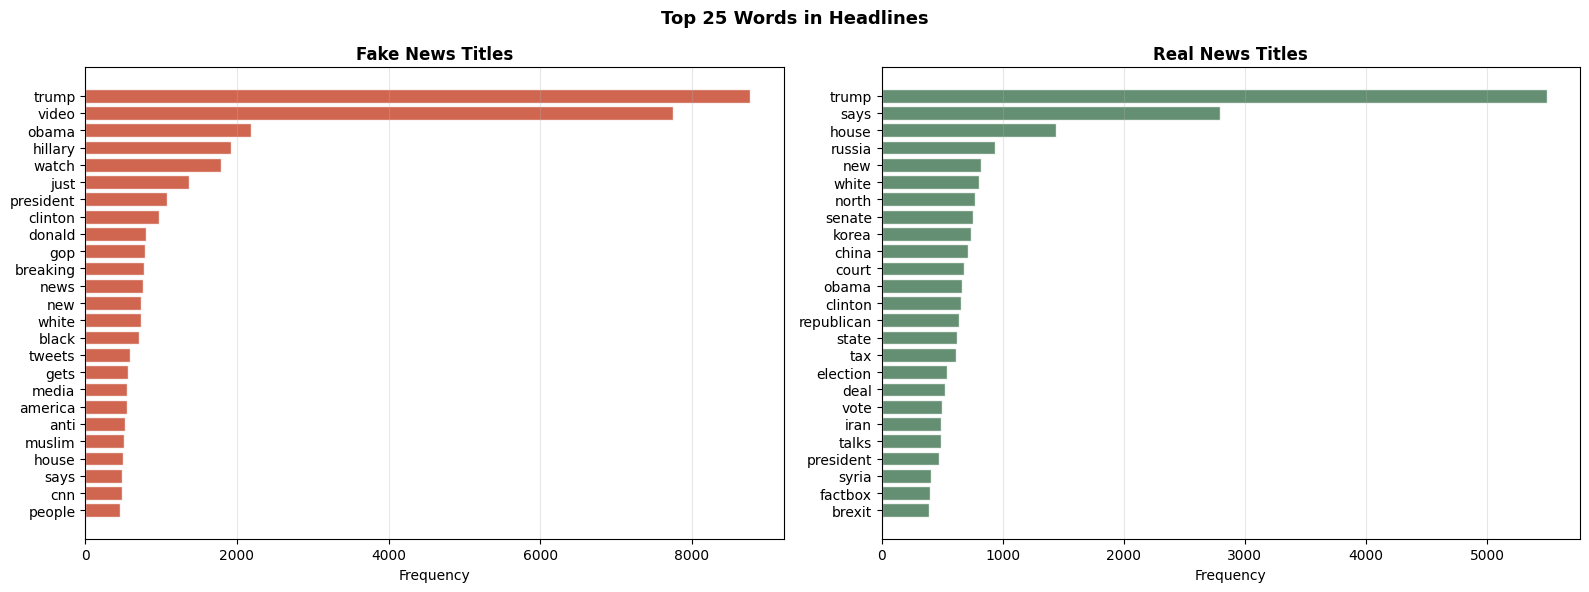


Top 10 fake title words: ['trump', 'video', 'obama', 'hillary', 'watch', 'just', 'president', 'clinton', 'donald', 'gop']
Top 10 real title words: ['trump', 'says', 'house', 'russia', 'new', 'white', 'north', 'senate', 'korea', 'china']


In [152]:
# ── Plot 5: Top words fake vs real ─────────────────────────────────

def get_top_words(texts, n=25):
    all_words = []
    for text in texts:
        if isinstance(text, str):
            words = re.sub(r"[^a-z\s]", " ", text.lower()).split()
            all_words.extend([w for w in words
                              if w not in ENGLISH_STOP_WORDS and len(w) > 2])
    return Counter(all_words).most_common(n)

fake_words = get_top_words(df[df["label"] == 0]["title"].tolist())
real_words = get_top_words(df[df["label"] == 1]["title"].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Top 25 Words in Headlines", fontsize=13, fontweight="bold")
for ax, words, color, title in [
    (axes[0], fake_words, "#c84b31", "Fake News Titles"),
    (axes[1], real_words, "#4a7c59", "Real News Titles"),
]:
    labels_w = [w[0] for w in words][::-1]
    counts_w = [w[1] for w in words][::-1]
    ax.barh(labels_w, counts_w, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Frequency"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("results/eda_05_top_words.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTop 10 fake title words: {[w[0] for w in fake_words[:10]]}")
print(f"Top 10 real title words: {[w[0] for w in real_words[:10]]}")

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 3. PREPROCESSING
# ══════════════════════════════════════════════════════════════════

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)        # letters only
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Drop rows with missing title or text
df = df.dropna(subset=["title", "text"])
df = df.drop_duplicates(subset=["title", "text"])
print(f"After cleaning: {df.shape}")

# Combine title + text — richer signal than either alone
df["combined"]  = (df["title"]  + " " + df["text"]).apply(clean_text)
val["combined"] = (val["title"].fillna("") + " " + val["text"].fillna("")).apply(clean_text)

print(f"Sample cleaned: {df['combined'].iloc[0][:150]}")



══ 3. PREPROCESSING ════════════════════════════════════════
After cleaning: (36429, 10)
Sample cleaned: as u s budget fight looms republicans flip their fiscal script washington reuters the head of a conservative republican faction in the u s congress wh


In [154]:
# ══════════════════════════════════════════════════════════════════
# 4. TRAIN / TEST SPLIT
# ══════════════════════════════════════════════════════════════════

X = df["combined"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")
print(f"Train balance: {y_train.value_counts().to_dict()}")
print(f"Test balance : {y_test.value_counts().to_dict()}")


Train size : 29,143
Test size  : 7,286
Train balance: {1: 15831, 0: 13312}
Test balance : {1: 3958, 0: 3328}


In [ ]:
# ══════════════════════════════════════════════════════════════════
# 5. FEATURE EXTRACTION — TF-IDF
# ══════════════════════════════════════════════════════════════════

tfidf = TfidfVectorizer(
    max_features = 50000,   #Keep only the 50,000 most important words/features
    ngram_range  = (1, 2),  #2-word combinations
    sublinear_tf = True,
    stop_words   = "english",   #removes common English words
    min_df       = 2,
)

X_train_tfidf = tfidf.fit_transform(X_train)  # fit on train only
X_test_tfidf  = tfidf.transform(X_test)
X_val_tfidf   = tfidf.transform(val["combined"])

print(f"TF-IDF shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF shape (test) : {X_test_tfidf.shape}")


TF-IDF shape (train): (29143, 50000)
TF-IDF shape (test) : (7286, 50000)


In [156]:
# ══════════════════════════════════════════════════════════════════
# TRAIN ALL MODELS
# ══════════════════════════════════════════════════════════════════

models = {
    # ── Baselines ────────────────────────────────────────────────
    "Naive Bayes":         MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0,
                                              solver="lbfgs", random_state=42),
    # ── Advanced ─────────────────────────────────────────────────
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=20,
                                                  random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100,
                                                       learning_rate=0.1,
                                                       random_state=42),
}


results = {}

for name, model in models.items():
    print(f"  Training {name}...", end=" ")
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    probs = model.predict_proba(X_test_tfidf)[:, 1]

    results[name] = {
        "model"    : model,
        "preds"    : preds,
        "probs"    : probs,
        "accuracy" : accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall"   : recall_score(y_test, preds),
        "f1"       : f1_score(y_test, preds),
        "auc_roc"  : roc_auc_score(y_test, probs),
    }
    print(f"done — acc: {results[name]['accuracy']*100:.2f}%")



  Training Naive Bayes... done — acc: 95.92%
  Training Logistic Regression... done — acc: 98.82%
  Training Random Forest... done — acc: 97.58%
  Training Gradient Boosting... done — acc: 99.53%



══ 8. EVALUATION ═══════════════════════════════════════════

Model                   Accuracy  Precision   Recall      F1   AUC-ROC
----------------------------------------------------------------------
  Naive Bayes            0.9592    0.9649   0.9598  0.9624   0.9924
  Logistic Regression    0.9882    0.9845   0.9939  0.9892   0.9994 ◄ baseline
  Random Forest          0.9758    0.9608   0.9962  0.9782   0.9988
  Gradient Boosting      0.9953    0.9945   0.9970  0.9957   0.9969


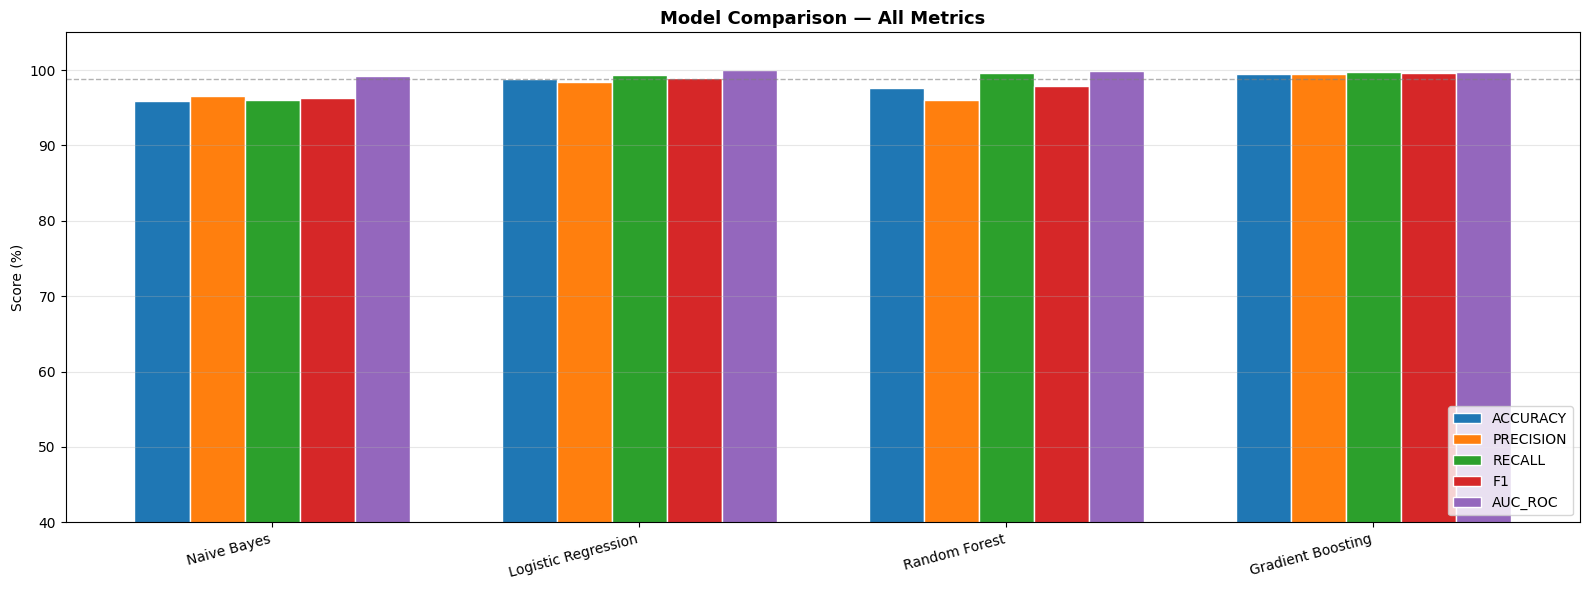

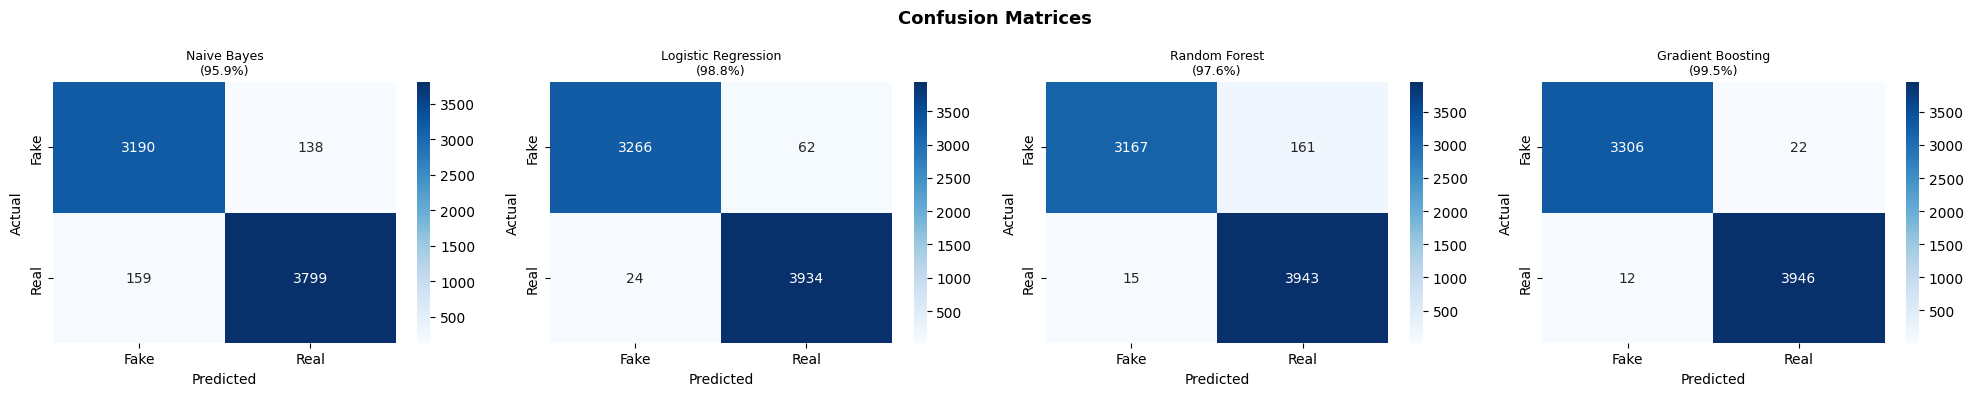

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 8. EVALUATE ALL MODELS
# ══════════════════════════════════════════════════════════════════

print(f"\n{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8}"
      f" {'F1':>7} {'AUC-ROC':>9}")
print("-" * 70)
for name, r in results.items():
    marker = " ◄ baseline" if name == "Logistic Regression" else ""
    print(f"  {name:<20} {r['accuracy']:>8.4f} {r['precision']:>9.4f}"
          f" {r['recall']:>8.4f} {r['f1']:>7.4f} {r['auc_roc']:>8.4f}{marker}")

# ── Plot: model comparison ─────────────────────────────────────────
metrics    = ["accuracy", "precision", "recall", "f1", "auc_roc"]
model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 6))
for i, metric in enumerate(metrics):
    vals = [results[n][metric] * 100 for n in model_names]
    bars = ax.bar(x + i * width, vals, width, label=metric.upper(),
                  edgecolor="white")

ax.set_title("Model Comparison — All Metrics", fontsize=13, fontweight="bold")
ax.set_xticks(x + width * 2)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylabel("Score (%)")
ax.set_ylim(40, 105)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
ax.axhline(y=results["Logistic Regression"]["accuracy"] * 100,
           color="gray", linestyle="--", linewidth=1,
           label="LR baseline", alpha=0.6)
plt.tight_layout()
plt.savefig("results/eval_01_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Confusion matrices for all real models ─────────────────────────
non_dummy = [n for n in model_names if n != "Majority Class"]
fig, axes = plt.subplots(1, len(non_dummy), figsize=(5 * len(non_dummy), 4))
fig.suptitle("Confusion Matrices", fontsize=13, fontweight="bold")

for ax, name in zip(axes, non_dummy):
    cm = confusion_matrix(y_test, results[name]["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Fake", "Real"],
                yticklabels=["Fake", "Real"])
    acc = results[name]["accuracy"] * 100
    ax.set_title(f"{name}\n({acc:.1f}%)", fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("results/eval_02_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


══ 9. BEST MODEL DEEP DIVE ═════════════════════════════════

Best model : Gradient Boosting
Accuracy   : 99.53%
AUC-ROC    : 99.69%

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       1.00      0.99      0.99      3328
    Real (1)       0.99      1.00      1.00      3958

    accuracy                           1.00      7286
   macro avg       1.00      1.00      1.00      7286
weighted avg       1.00      1.00      1.00      7286



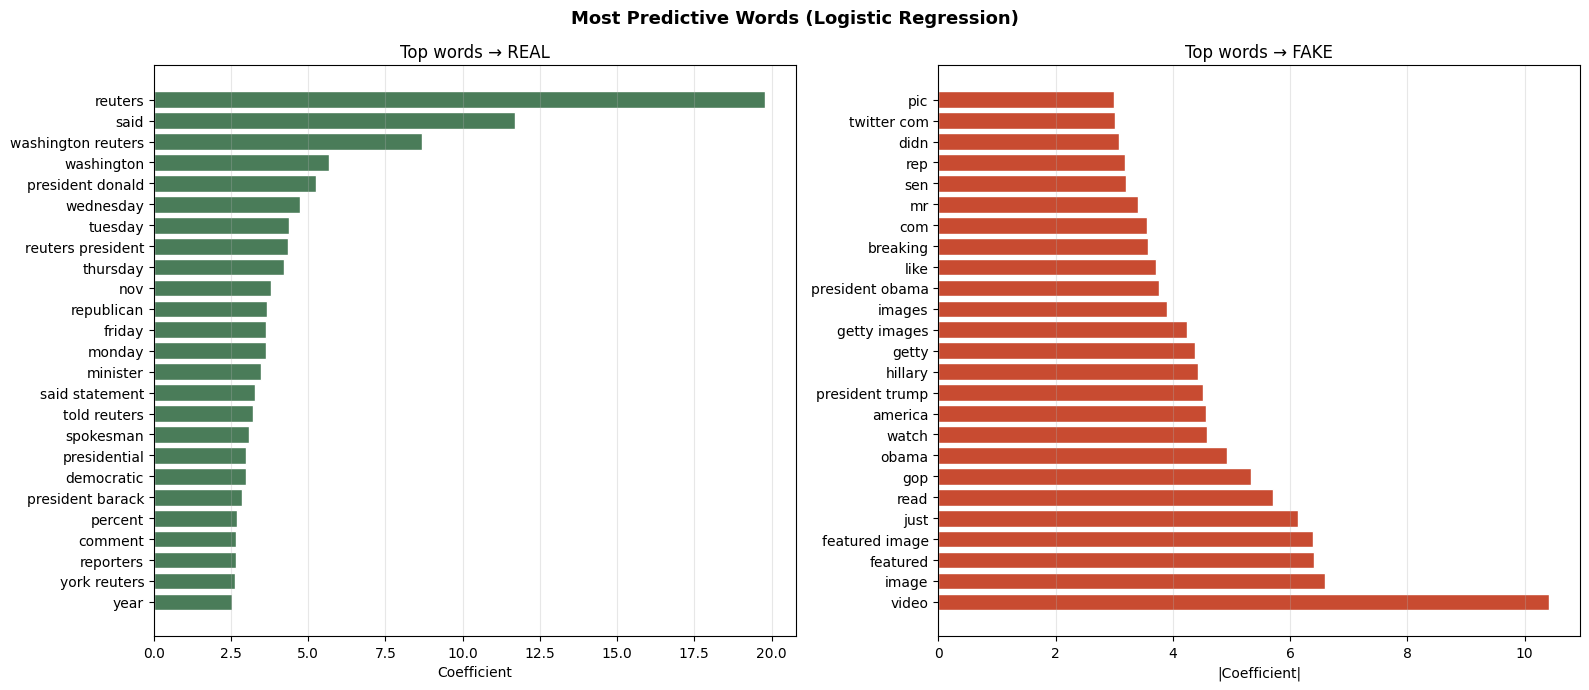


Total errors   : 34 / 7286
False Positives: 22 (predicted Real, actually Fake)
False Negatives: 12 (predicted Fake, actually Real)

Sample misclassified headlines:
  [FAKE] PANIC! REUTERS/IPSOS Will Radically Change Way They Poll After Trump Takes Commanding 17 P
  [FAKE] FBI DATA Shows Black-On-Black Murders Off The Charts During Obama Presidency…So Why Is Oba
  [FAKE] THE SECRET BEHIND AMERICA’S LOVE AFFAIR WITH TRUMP [Video]
  [FAKE] Saudi Man Threatens Backlash Over New Law Allowing Women Drivers: ‘I will burn her and her
  [REAL] U.S. Supreme Court turns away companies in California tax dispute


In [158]:
# ══════════════════════════════════════════════════════════════════
# 9. BEST MODEL — DEEP DIVE
# ══════════════════════════════════════════════════════════════════

print("\n══ 9. BEST MODEL DEEP DIVE ═════════════════════════════════")

best_name  = max(results, key=lambda k: results[k]["accuracy"])
best       = results[best_name]

print(f"\nBest model : {best_name}")
print(f"Accuracy   : {best['accuracy']*100:.2f}%")
print(f"AUC-ROC    : {best['auc_roc']*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, best["preds"],
                             target_names=["Fake (0)", "Real (1)"]))

# ── Top predictive words (Logistic Regression only) ────────────────
lr = results["Logistic Regression"]["model"]
feature_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]

top_real_idx = np.argsort(coefs)[-25:][::-1]
top_fake_idx = np.argsort(coefs)[:25]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Most Predictive Words (Logistic Regression)",
             fontsize=13, fontweight="bold")

axes[0].barh([feature_names[i] for i in top_real_idx[::-1]],
             [coefs[i] for i in top_real_idx[::-1]],
             color="#4a7c59", edgecolor="white")
axes[0].set_title("Top words → REAL"); axes[0].set_xlabel("Coefficient")
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh([feature_names[i] for i in top_fake_idx],
             [abs(coefs[i]) for i in top_fake_idx],
             color="#c84b31", edgecolor="white")
axes[1].set_title("Top words → FAKE"); axes[1].set_xlabel("|Coefficient|")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("results/best_01_top_features.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Error analysis — what did the model get wrong? ─────────────────
test_df = X_test.reset_index(drop=True).to_frame()
test_df["true"]      = y_test.reset_index(drop=True)
test_df["predicted"] = best["preds"]
errors = test_df[test_df["true"] != test_df["predicted"]]

print(f"\nTotal errors   : {len(errors)} / {len(X_test)}")
print(f"False Positives: {((best['preds']==1) & (y_test.values==0)).sum()} "
      f"(predicted Real, actually Fake)")
print(f"False Negatives: {((best['preds']==0) & (y_test.values==1)).sum()} "
      f"(predicted Fake, actually Real)")

print(f"\nSample misclassified headlines:")
misclassified = df.loc[X_test.index[test_df["true"] != test_df["predicted"]]]
for _, row in misclassified.head(5).iterrows():
    actual = "FAKE" if row["label"] == 0 else "REAL"
    print(f"  [{actual}] {str(row['title'])[:90]}")



In [ ]:
# ══════════════════════════════════════════════════════════════════
# 10. PREDICT ON VALIDATION SET
# ══════════════════════════════════════════════════════════════════

print("\n══ 10. VALIDATION PREDICTIONS ══════════════════════════════")

best_model = results[best_name]["model"]
val_preds  = best_model.predict(X_val_tfidf)

output = val.copy()
output["label"] = val_preds
output = output.drop(columns=["combined"]) # not needed in final output
output.to_csv("results/validation_data.csv", index=False)

print(f"Model used    : {best_name}")
print(f"Fake (0)      : {(val_preds == 0).sum():,}")
print(f"Real (1)      : {(val_preds == 1).sum():,}")
print(f"Saved         → results/validation_data.csv")

# Quick sanity check — no 2s should remain
assert (output["label"] == 2).sum() == 0, "ERROR: label=2 still present!"
print("Sanity check  : ✓ no label=2 remaining")



══ 10. VALIDATION PREDICTIONS ══════════════════════════════
Model used    : Gradient Boosting
Fake (0)      : 3,463
Real (1)      : 1,493
Saved         → results/validation_data.csv
Sanity check  : ✓ no label=2 remaining
